Unique categories: ['Keamanan/Privasi' 'Bunga/Biaya Tinggi' 'Kemudahan Akses' 'Penagihan']
Unique emotions: ['Takut' 'Senang' 'Kecewa' 'Marah']


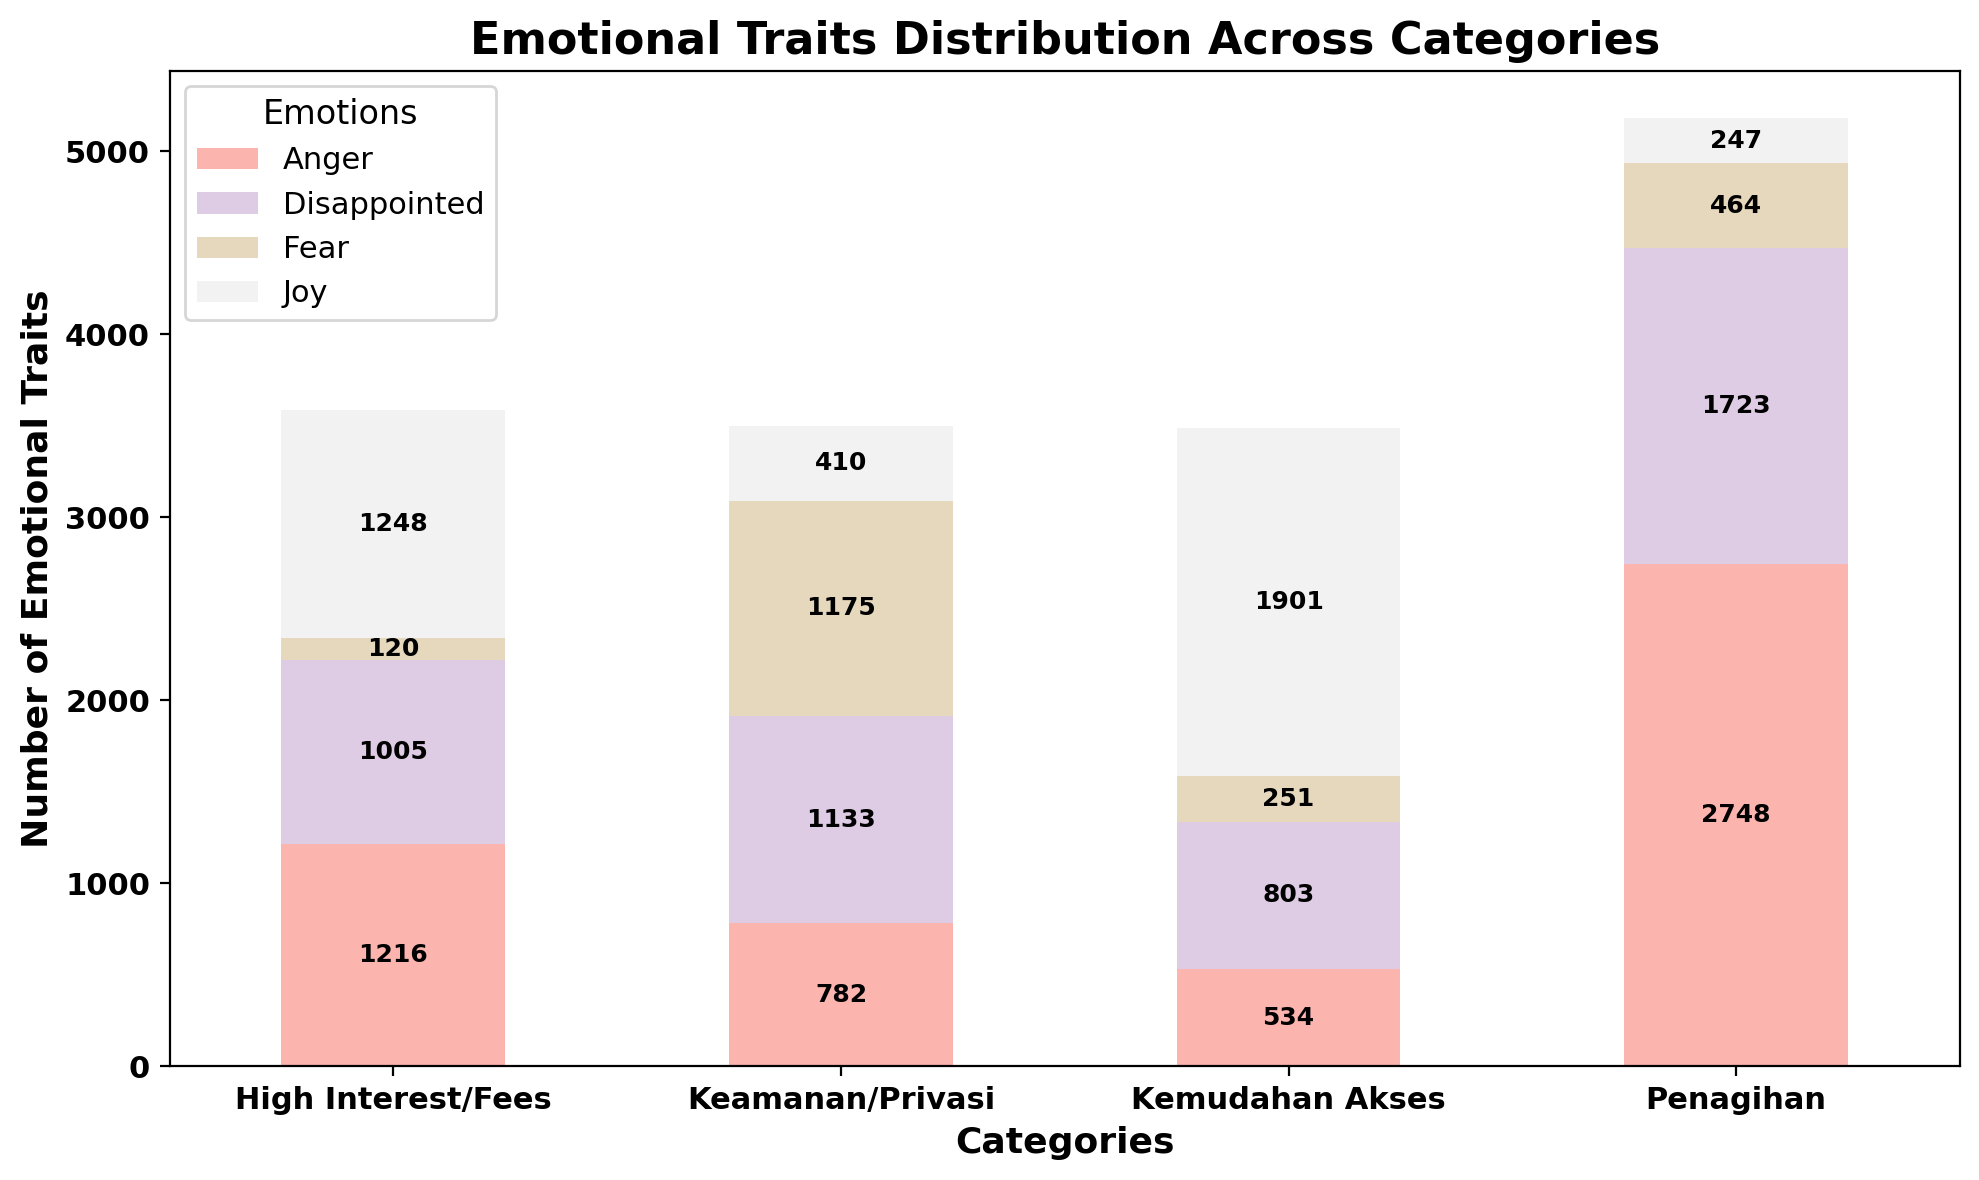

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Contoh dataset (ganti pakai datasetmu)
# df = pd.read_csv("dataset.csv")

# Cek nilai unik di dataset terlebih dahulu
print("Unique categories:", df["kategori"].unique())
print("Unique emotions:", df["emosi"].unique())

# Mapping nama kategori ke bahasa Inggris
category_rename_map = {
    "Aksesibilitas": "Accessibility",
    "Penagihan Utang": "Debt Collection",
    "Bunga/Biaya Tinggi": "High Interest/Fees",
    "Privasi": "Privacy",
    # Tambahkan variasi lain jika ada
    "penagihan utang": "Debt Collection",
    "bunga/biaya tinggi": "High Interest/Fees",
    "aksesibilitas": "Accessibility",
    "privasi": "Privacy"
}

# Mapping nama emosi ke bahasa Inggris
emotion_rename_map = {
    "Marah": "Anger",
    "Kecewa": "Disappointed",
    "Takut": "Fear",
    "Senang": "Joy",
    # Tambahkan variasi lain jika ada
    "marah": "Anger",
    "kecewa": "Disappointed",
    "takut": "Fear",
    "senang": "Joy"
}

# Rename kategori dan emosi dengan fallback ke nilai asli jika tidak ada mapping
df_renamed = df.copy()
df_renamed["kategori"] = df_renamed["kategori"].map(category_rename_map).fillna(df_renamed["kategori"])
df_renamed["emosi"] = df_renamed["emosi"].map(emotion_rename_map).fillna(df_renamed["emosi"])

# Hitung jumlah emosi per kategori
counts = df_renamed.groupby(["kategori", "emosi"]).size().unstack(fill_value=0)

# Set resolusi tinggi
plt.figure(figsize=(10,6), dpi=200)

# Plot stacked bar
ax = counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="Pastel1",   # pakai pastel biar angka jelas
    ax=plt.gca()
)

# Judul dan label
plt.title("Emotional Traits Distribution Across Categories", fontsize=16, fontweight="bold")
plt.xlabel("Categories", fontsize=13, fontweight="bold")
plt.ylabel("Number of Emotional Traits", fontsize=13, fontweight="bold")
plt.xticks(rotation=0, fontsize=11, fontweight="bold")
plt.yticks(fontsize=11, fontweight="bold")

# Tambahkan angka di tengah bar dengan warna kontras otomatis
for container in ax.containers:
    for bar in container:
        if bar.get_height() > 0:
            height = bar.get_height()
            xpos = bar.get_x() + bar.get_width() / 2
            ypos = bar.get_y() + height / 2

            # Ambil warna bar
            color = np.array(bar.get_facecolor()[:3]) * 255
            brightness = np.mean(color)

            # Tentukan warna teks (kontras)
            text_color = "black" if brightness > 180 else "white"

            ax.text(
                xpos, ypos,
                f"{int(height)}",
                ha="center", va="center",
                fontsize=9, fontweight="bold",
                color=text_color
            )

# Legend
plt.legend(title="Emotions", fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()